In [1]:
import pandas as pd
import sys

sys.path.append('../python_scripts')





In [6]:

run_name_1 = '2d_4obj_1_val'
df_median = pd.read_parquet("../sim_results/{}/median_objectives".format(run_name_1))
df_median.to_parquet('../sim_results/{}/median_objectives.parquet'.format(run_name_1))
df1 = pd.read_parquet('../sim_results/{}/median_objectives.parquet'.format(run_name_1)).reset_index()
df_pivot_1 = pd.pivot_table(df1[['mode', 'objective', 'sim_id', 'value']], index = 'sim_id', values = 'value', columns = ['mode', 'objective'])

In [19]:
run_name_2 = '2d_4obj_2_val'
df_median = pd.read_parquet("../sim_results/{}/median_objectives".format(run_name_2))
df_median.to_parquet('../sim_results/{}/median_objectives.parquet'.format(run_name_2))
df2 = pd.read_parquet('../sim_results/{}/median_objectives.parquet'.format(run_name_2)).reset_index()
df_pivot_2 = pd.pivot_table(df1[['mode', 'objective', 'sim_id', 'value']], index = 'sim_id', values = 'value', columns = ['mode', 'objective'])
df_pivot_2

mode                     train                                               \
objective    28_day_percentile 28_day_regret drawdown      mean mean_regret   
sim_id                                                                        
03b370febf4c         -0.071033      0.061229      0.0  0.647343   -0.305304   
05c8b01a7751         -0.084183      0.079334      0.0  0.682245   -0.340206   
0699b15d2feb         -0.085666      0.076684      0.0  0.693972   -0.351932   
07b0e48fc241         -0.113394      0.083236      0.0  0.424037   -0.081997   
0f28874db000         -0.083385      0.075572      0.0  0.659037   -0.316997   
...                        ...           ...      ...       ...         ...   
f36832a3f712         -0.080993      0.076249      0.0  0.730036   -0.387996   
f85fb851fe46         -0.084289      0.079186      0.0  0.719962   -0.377923   
f9a80facd695         -0.014044      0.037775      0.0  0.335269    0.006770   
fc4187d547b5         -0.086327      0.080342      0.0  0.690038   -0.347998   
ff0cb861605f         -0.084341      0.078869      0.0  0.736346   -0.394306   

mode                                                 val                \
objective     quantile regret_quantile 28_day_percentile 28_day_regret   
sim_id                                                                   
03b370febf4c  0.647343       -0.305304         -0.103864      0.051724   
05c8b01a7751  0.682245       -0.340206         -0.113530      0.054177   
0699b15d2feb  0.693972       -0.351932         -0.110709      0.059446   
07b0e48fc241  0.424037       -0.081997         -0.127046      0.059499   
0f28874db000  0.659037       -0.316997         -0.125168      0.065907   
...                ...             ...               ...           ...   
f36832a3f712  0.730036       -0.387996         -0.125181      0.059938   
f85fb851fe46  0.719962       -0.377923         -0.117735      0.061961   
f9a80facd695  0.335269        0.006770         -0.054568      0.047815   
fc4187d547b5  0.690038       -0.347998         -0.125052      0.067072   
ff0cb861605f  0.736346       -0.394306         -0.120048      0.062850   

mode                                                                    
objective     drawdown      mean mean_regret  quantile regret_quantile  
sim_id                                                                  
03b370febf4c  0.045582  1.039530   -0.869281 -0.500296       -8.602935  
05c8b01a7751  0.041929  1.148903   -0.978654 -0.472514       -9.169944  
0699b15d2feb  0.080497  0.957225   -0.786976 -0.470530       -6.920564  
07b0e48fc241  0.055687  1.010022   -0.839773 -0.475039       -7.425145  
0f28874db000  0.053798  1.043829   -0.873580 -0.460480       -9.485383  
...                ...       ...         ...       ...             ...  
f36832a3f712  0.083329  1.011826   -0.841577 -0.494605       -8.339314  
f85fb851fe46  0.045557  1.189905   -1.019655 -0.533542      -10.375549  
f9a80facd695  0.033013  0.572691   -0.402442 -0.299621       -3.131919  
fc4187d547b5  0.053466  1.128751   -0.958501 -0.545877      -10.607270  
ff0cb861605f  0.052651  1.224252   -1.054003 -0.543038      -10.639861  

[62 rows x 14 columns]

In [12]:
df2_add = df_pivot_2[[('train', '28_day_percentile'), ('train', 'drawdown')]]
df2_add.columns = [x[1] for x in df2_add.columns]
df2_add
df2

,mode,objective,value,sim_id,gen
0,train,28_day_percentile,-0.073674,03b370febf4c,0
1,train,28_day_regret,0.057379,03b370febf4c,0
2,train,drawdown,0.123971,03b370febf4c,0
3,train,mean,0.371944,03b370febf4c,0
4,train,mean_regret,-0.236722,03b370febf4c,0
...,...,...,...,...,...
863,val,drawdown,0.050602,ff0cb861605f,0
864,val,mean,1.177460,ff0cb861605f,0
865,val,mean_regret,-1.007211,ff0cb861605f,0
866,val,quantile,-0.517153,ff0cb861605f,0


In [9]:

from utils import get_pareto_layers, get_dna_hash

gen = 99
df_gen = df.loc[df['gen'] == gen]
df_pivot = pd.pivot_table(df_gen[['mode', 'objective', 'sim_id', 'value']], index = 'sim_id', values = 'value', columns = ['mode', 'objective'])
df_layers = get_pareto_layers(df_pivot[[('train','mean_regret'), ('train','regret_quantile'), ('train', '28_day_percentile'), ('train', 'drawdown')]], sense = ['min', 'min', 'max', 'min'], num_layers=1)
pareto_indices = df_layers.loc[df_layers.layer==0].index
df_add = df_pivot.loc[pareto_indices]
df_add['gen'] = gen


In [51]:
sim_ids = df_add.index
df_gen = pd.read_parquet('s3://jdinvestment/{}/populations/gen_99.parquet'.format(run_name))
df_gen = df_gen.loc[sim_ids]
df_gen.to_parquet('s3://jdinvestment/2d_4obj_1_val/gen_0.parquet')
df_folds = pd.read_parquet('s3://jdinvestment/2d_4obj_1/folds.parquet')
df_folds.to_parquet('s3://jdinvestment/2d_4obj_1_val/folds.parquet')


In [41]:
df1 = df_add[[('train', 'drawdown'), ('train', '28_day_percentile'), ('train', 'mean')]]
df1.columns = [x[1] for x in df1.columns]
df1



,drawdown,28_day_percentile,mean
sim_id,,,
03b370febf4c,0.119663,-0.080864,0.370863
05c8b01a7751,0.122495,-0.045245,0.193599
0699b15d2feb,0.091319,-0.070570,0.323638
07b0e48fc241,0.113801,-0.066724,0.245613
0f28874db000,0.129139,-0.067327,0.363214
...,...,...,...
f36832a3f712,0.105960,-0.068762,0.364005
f85fb851fe46,0.127685,-0.075839,0.365309
f9a80facd695,0.126604,-0.076030,0.386490


In [42]:
import plotly.express as px

# Resetting the index makes it a standard column accessible for hover tooltips, 
# and including 'drawdown' lets you see all three variables at once.
fig = px.scatter(
    df1.reset_index(), 
    x='28_day_percentile', 
    y='mean', 
    hover_data=['sim_id', 'drawdown']
)
fig.show()

In [45]:
prefix = '838'
df_add.loc[df_add.index.str.startswith(prefix)].transpose()

sim_id                   838abd173b4b
mode  objective                      
train 28_day_percentile     -0.030083
      28_day_regret          0.045205
      drawdown               0.167483
      mean                   0.035263
      mean_regret            0.099958
      quantile              -0.186830
      regret_quantile       -0.091261
val   28_day_percentile     -0.050473
      28_day_regret          0.047894
      drawdown               0.029165
      mean                   1.273996
      mean_regret           -1.032479
      quantile              -0.351580
      regret_quantile       -4.718696
gen                         99.000000

In [34]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.mcdm.high_tradeoff import HighTradeoffPoints
import numpy as np
import pandas as pd

def find_diminishing_return_points(df, cols=['28_day_regret', 'drawdown', 'mean_regret']):
    # Extract objective matrix (all three are minimized)
    F = df[cols].values
    
    # 1. Isolate the Pareto-optimal front
    fronts = NonDominatedSorting().do(F)
    pareto_indices = fronts[0]
    F_pareto = F[pareto_indices]
    
    # 2. Normalize objectives to [0, 1] using Pareto bounds 
    ideal = F_pareto.min(axis=0)
    nadir = F_pareto.max(axis=0)
    range_vals = nadir - ideal
    range_vals[range_vals == 0] = 1.0  # Guard against zero variance
    
    F_normalized = (F_pareto - ideal) / range_vals
    
    # 3. Extract high-tradeoff / knee points using pymoo
    dm = HighTradeoffPoints()
    local_knee_indices = dm(F_normalized)
    
    # Map back to the original dataframe row indices
    original_knee_indices = pareto_indices[local_knee_indices]
    
    return df.iloc[original_knee_indices]


df2 = find_diminishing_return_points(df1)
df2

              drawdown  28_day_regret  mean_regret
sim_id                                            
ccd0834b2fdb  0.087684       0.053060    -0.186214
ff0cb861605f  0.129651       0.048528    -0.254243
              drawdown  28_day_regret  mean_regret
sim_id                                            
ccd0834b2fdb  0.087684       0.053060    -0.186214
ff0cb861605f  0.129651       0.048528    -0.254243


KeyError: "None of [Index([44, 61], dtype='int64', name='sim_id')] are in the [index]"

In [32]:
import pymoo.utils

ModuleNotFoundError: No module named 'pymoo.utils'

In [32]:
df = df_add[[('val', '28_day_percentile'), ('val', 'mean')]].sort_values(by = ('val', '28_day_percentile'))
import plotly.express as px
fig = px.scatter(x = df.iloc[:,0], y = df.iloc[:,1])
fig.show()
df

mode                       val          
objective    28_day_percentile      mean
sim_id                                  
f09639f3924a         -0.047053  0.431657
0b121af9e6e8         -0.046715  0.395982
a287cbb68d48         -0.043409  0.354460
990cd887983b         -0.043131  0.378544
67b7821103a2         -0.042934  0.420323
8cb6b3b98866         -0.042539  0.403631
1654fede4902         -0.042275  0.393434
908aed681dce         -0.041517  0.331467
8c643592d566         -0.041397  0.421022
6ef59107c4b4         -0.040883  0.299052
08860a4591a7         -0.040781  0.417785
a6b5aad5a39a         -0.040658  0.372195
951ccdf6ead8         -0.040390  0.372792
9abe3b25e84e         -0.040046  0.392824
62a02dfb344a         -0.039892  0.355052
1fe573c4b9d7         -0.038059  0.410299
21a7ee0a7968         -0.037230  0.388941
b5687dcef111         -0.036494  0.392951
7ebd9e8a3683         -0.026915  0.270525

Gross Structure Knee X: -0.03649443478064919
Gross Structure Knee Y: 0.3929508216897269
Gross Structure Knee Index: 17
b5687dcef111


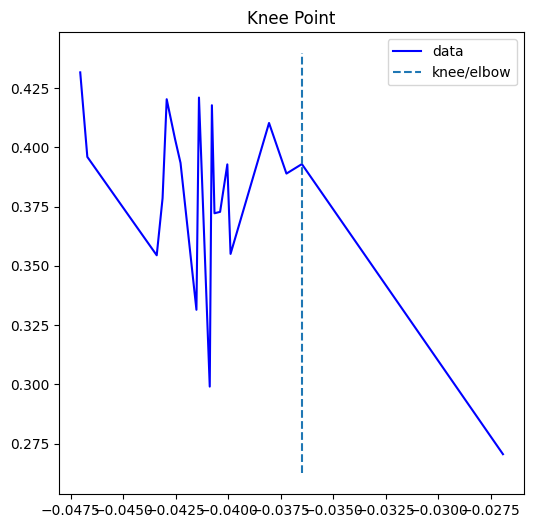

In [56]:
import numpy as np
from kneed import KneeLocator

# Generate sample x data and noisy y data clustered around a curve
x = df.iloc[:, 0] 
y = df.iloc[:, 1]

kneedle = KneeLocator(
    x, y, 
    curve='concave',        # Arch/hill shape (concave down)
    direction='decreasing',  # y decreases as x increases
    S=3.0,                   # Higher sensitivity to bypass local start-of-curve noise
    online=False,            # Forces global evaluation instead of trapping on early local dips
    interp_method='polynomial', 
    polynomial_degree=3      # Smooths out scatter to target the gross structure
)

# Find the index of the point closest to the knee X-value
# .idxmin() works for pandas Series (returns index label); use np.argmin for positional integer index
knee_index = (x - kneedle.knee).abs().argmin()

print(f"Gross Structure Knee X: {kneedle.knee}")
print(f"Gross Structure Knee Y: {kneedle.knee_y}")
print(f"Gross Structure Knee Index: {knee_index}")


sim_id = (x - kneedle.knee).abs().idxmin()
print(sim_id)

kneedle.plot_knee()

In [68]:
df_pop = pd.read_parquet('s3://jdinvestment/{}/populations/gen_99.parquet'.format(run_name))

print(np.where(df_pop.index == sim_id)[0][0], df_pop.shape)
df_pop.loc[df_pop.index == sim_id].transpose()

10 (215, 22)


,b5687dcef111
dollar_ret_1p,0.000153
dollar_ret_6p,0.560173
dollar_ret_13p,0.542503
dollar_ret_26p,0.382811
avg_eps_1q,0.296303
avg_eps_2q,0.025689
avg_eps_4q,0.837020
avg_eps_8q,0.065425
threshold,0.509762
beta,1.125721


In [ ]:
df_all_pop = pd.DataFrame()
for gen in range(100):
    df_add = pd.read_parquet('s3://jdinvestment/{}/populations/gen_{}.parquet'.format(run_name, gen))
    df_add['gen'] = gen
    df_all_pop = pd.concat([df_all_pop, df_add])
df_agg = df_all_pop[['gen', 'max_frac']].groupby('gen').agg('mean')
fig = px.scatter(x = df_agg.index, y = df_agg.max_frac)
fig.show()

: 

In [ ]:
from utils import get_pareto_layers

df_pareto = pd.DataFrame()
df_1  = pd.DataFrame()
for gen in df['gen'].drop_duplicates():
    df_gen = df.loc[df['gen'] == gen]
    df_pivot = pd.pivot_table(df_gen[['mode', 'objective', 'sim_id', 'value']], index = 'sim_id', values = 'value', columns = ['mode', 'objective'])
    df_layers = get_pareto_layers(df_pivot[[('train','mean_regret'), ('train','regret_quantile'), ('train', '28_day_percentile')]], sense = ['min', 'min'], num_layers=1)
    pareto_indices = df_layers.loc[df_layers.layer==0].index
    df_add = df_pivot.loc[pareto_indices]
    df_add['gen'] = gen
    argmin = int(df_add[('train', 'mean_regret')].argmin())
    df_add_1 = pd.DataFrame(df_add.iloc[argmin]).transpose() 
    df_1 = pd.concat([df_1, df_add_1])
    df_pareto = pd.concat([df_pareto, df_add])
    
df_pareto.to_parquet('../sim_results/{}/train_pareto_by_gen.parquet'.format(run_name))


KeyboardInterrupt: 

In [48]:
#get initial population for new run with max_frac as pymoo variable

from utils import get_pareto_layers, get_dna_hash
import numpy as np

df_gen = df.loc[df['gen'] == max(df['gen'])]
df_pivot = pd.pivot_table(df_gen[['mode', 'objective', 'sim_id', 'value']], index = 'sim_id', values = 'value', columns = ['mode', 'objective'])
df_layers = get_pareto_layers(df_pivot[[('train','mean_regret'), ('train','regret_quantile')]], sense = ['min', 'min'], num_layers=15)
df_layers.layer.value_counts(normalize = True).sort_index().cumsum()
sim_ids = df_layers.loc[df_layers.layer <= 12].index
df1 = pd.read_parquet('s3://jdinvestment/{}/populations/gen_149.parquet'.format(run_name)).loc[sim_ids]
df1['max_frac'] = .05
df2 = pd.read_parquet('s3://jdinvestment/{}/populations/gen_149.parquet'.format(run_name)).loc[sim_ids]
df2['max_frac'] = np.random.uniform(.05, .1, size=df2.shape[0])
df_out = pd.concat([df1, df2]).iloc[:215]
best_index = int(np.where(df_out.index == '2c9631a5d785')[0][0])
df_out.index = df_out.apply(get_dna_hash, axis =1)
df_out.to_parquet('s3://jdinvestment/2d_3obj/populations/gen_0.parquet')



In [49]:
best_index


19

In [16]:
#ALTERNATIVE
from utils import get_pareto_layers

df_pareto = pd.DataFrame()
df_1  = pd.DataFrame()
for gen in sorted(list(df['gen'].drop_duplicates())):
    df_gen = df.loc[df['gen'] == gen]
    df_pivot = pd.pivot_table(df_gen[['mode', 'objective', 'sim_id', 'value']], index = 'sim_id', values = 'value', columns = ['mode', 'objective'])
    #df_layers = get_pareto_layers(df_pivot[[('train','mean_regret'), ('train','regret_quantile')]], sense = ['min', 'min'], num_layers=1)
    #pareto_indices = df_layers.loc[df_layers.layer==0].index
    df_add = df_pivot
    df_add['gen'] = gen
    argmin = int(df_add[('train', 'mean_regret')].argmin())
    df_add_1 = pd.DataFrame(df_add.iloc[argmin]).transpose()
    df_add_1['sim_id'] = df_add_1.index
    df_1 = pd.concat([df_1, df_add_1])
    df_pareto = pd.concat([df_pareto, df_add])
   
    
    
df_pareto.to_parquet('../sim_results/{}/train_pareto_by_gen.parquet'.format(run_name))

In [6]:
import numpy as np
sim_id = df_1.loc[df_1.gen == 149].index[0]
s_values = pd.read_parquet('s3://jdinvestment/{}/portfolio_values/sim_{}.parquet'.format(run_name, sim_id)).transpose().iloc[:-3]
df_pop = pd.read_parquet("s3://jdinvestment/{}/populations/gen_149.parquet".format(run_name))
sim_index = int(np.where(df_pop.index == sim_id)[0][0])
print(sim_index, sim_id, (s_values.iloc[-1]/s_values.iloc[-14])**(1/1), s_values.index[-14], s_values.index[-1])

149 2c9631a5d785 2c9631a5d785    1.186214
dtype: object 2025-05-19_00:00:00 2026-05-18_00:00:00


In [23]:
def find_first_date_after(date_list, target_date):
    # Filter dates strictly greater than the target date, then find the minimum
    future_dates = [d for d in date_list if d > target_date]
    return min(future_dates) if future_dates else None

In [32]:
from datetime import date, timedelta
import pandas as pd
import requests

def get_vgro_prices(val_start_date: date, api_token = '693327461e9541.04731237') -> pd.Series:
    """
    Fetches daily data for VGRO.TO from EODHD starting from val_start_date,
    builds a 28-day stepping schedule, and returns a pandas Series of prices
    indexed by date.
    """
    today = date.today()
    
    # 1. Fetch historical EOD data from EODHD
    # Pulling from val_start_date to today
    url = f"https://eodhistoricaldata.com/api/eod/VGRO.TO"
    params = {
        "api_token": api_token,
        "fmt": "json",
        "from": val_start_date.isoformat(),
        "to": today.isoformat()
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    
    # Convert to pandas DataFrame
    df = pd.DataFrame(data)
    if df.empty:
        return pd.Series(dtype=float)
        
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    
    # Use adjusted close ('adjusted_close') if available, otherwise standard 'close'
    price_col = 'adjusted_close' if 'adjusted_close' in df.columns else 'close'
    
    # 2. Generate target 28-day sequence of dates
    target_dates = []
    curr_date = pd.Timestamp(val_start_date)
    end_timestamp = pd.Timestamp(today)
    
    while curr_date <= end_timestamp:
        target_dates.append(curr_date)
        curr_date += timedelta(days=28)
        
    # 3. Match target dates to available trading days (using merge_asof or reindexing)
    # Reindex the dataframe to our target schedule and use 'nearest' or 'ffill' 
    # to find valid trading prices if a 28-day mark falls on a weekend/holiday.
    price_series = df[price_col]
    
    target_index = pd.DatetimeIndex(target_dates)
    
    # Reindex with tolerance to find the closest available trading day (e.g., within 3 days)
    matched_prices = price_series.reindex(target_index, method='nearest', tolerance=pd.Timedelta(days=3))
    
    # Drop any NaNs if a date fell completely outside available bounds
    matched_prices.dropna(inplace=True)
    
    return matched_prices

# Example usage:
# api_token = "YOUR_EODHD_API_KEY"
# start_date = date(2025, 1, 1)
# vgro_series = get_vgro_28day_prices(start_date, api_token)
# print(vgro_series)

In [44]:

df_history = pd.read_parquet('s3://jdinvestment/{}/holdings/sim_{}.parquet'.format(run_name, sim_id))
s_values = df_history.set_index('date').drop('sim_id', axis = 1).sum(1)
df_folds = pd.read_parquet('../strategy/folds_4.parquet')
val_start_date = find_first_date_after(s_values.index, df_folds.loc[df_folds.fold_index == 1].iloc[0].start_date+ pd.Timedelta(days=365)) 
end_date = s_values.index[-1]
num_years = (end_date - val_start_date).days/365.25
s_vgro = get_vgro_prices(val_start_date)

print(num_years, (s_values.loc[end_date]/s_values.loc[val_start_date])**(1/num_years))
print(3, (s_values.iloc[-1]/s_values.iloc[-40])**(1/3))
print(1, (s_values.iloc[-1]/s_values.iloc[-14]))
print(s_values.index[-1])
print((47.04/31.62)**(1/4.5))

3.4496919917864477 1.290441346344342
3 1.321279758067227
1 1.173925822336708
2026-06-15 00:00:00
1.092281414043957


In [42]:
val_start_date + pd.Timedelta(days=365)

Timestamp('2023-01-03 00:00:00')

In [45]:
import plotly.graph_objects as go

fig = go.Figure()
start_date = val_start_date - pd.Timedelta(days = 28)
s_keep = s_values.loc[s_values.index >= val_start_date ]
fig.add_trace(go.Scatter(x = s_keep.index, y = s_keep.values/s_keep.values[0], name = 'algorithm'))
fig.add_trace(go.Scatter(x= s_vgro.index, y = s_vgro.values/s_vgro.values[0], name = 'vgro'))
fig.show()


In [17]:
's3://jdinvestment/{}/holdings/sim_{}.parquet'.format(run_name, sim_id)

's3://jdinvestment/2d_train_to_2025/holdings/sim_8a5b8b45a1c0.parquet'

In [15]:
(s_values.iloc[-1]/s_values.iloc[0])**(13/(len(s_values)-1)), len(s_values)-1

(np.float64(1.2922609296546819), 12)

In [10]:
s_values

,8a5b8b45a1c0
date,
2025-06-16_00:00:00,297444.22
2025-07-14_00:00:00,307416.8367
2025-08-11_00:00:00,314237.0451
2025-09-08_00:00:00,314665.3433
2025-10-06_00:00:00,335636.2684
2025-11-03_00:00:00,342644.3385
2025-12-01_00:00:00,342866.9907
2025-12-29_00:00:00,343344.6647
2026-01-26_00:00:00,359634.9646


In [7]:
s_train_regret = (df_pareto[[('train', 'mean_regret'), ('gen','')]]).groupby('gen').agg('mean').iloc[:,0]
s_val_regret = (df_pareto[[('val', 'mean_regret'), ('gen','')]]).groupby('gen').agg('mean').iloc[:,0]
s_val= (df_pareto[[('val', 'mean'), ('gen','')]]).groupby('gen').agg('mean').iloc[:,0]
fig = go.Figure()
fig.add_trace(go.Scatter(x = s_train_regret.index.values, y = s_train_regret.values, name = 'train_regret'))
fig.add_trace(go.Scatter(x = s_val_regret.index, y = s_val_regret.values, name = 'val_regret'))
fig.add_trace(go.Scatter(x = s_val.index, y = s_val.values, name = 'val'))
fig.show()

In [ ]:
df_1.columns

MultiIndex([('train',            'mean'),
            ('train',     'mean_regret'),
            ('train',        'quantile'),
            ('train', 'regret_quantile'),
            (  'val',            'mean'),
            (  'val',     'mean_regret'),
            (  'val',        'quantile'),
            (  'val', 'regret_quantile'),
            (  'gen',                '')],
           names=['mode', 'objective'])

: 

In [8]:
import plotly.graph_objects as go 
s_train_regret = (df_1[[('train', 'mean_regret'), ('gen','')]]).groupby('gen').agg('mean').iloc[:,0]
s_val_regret = (df_1[[('val', 'mean_regret'), ('gen','')]]).groupby('gen').agg('mean').iloc[:,0]
s_val = (df_1[[('val', 'mean'), ('gen','')]]).groupby('gen').agg('mean').iloc[:,0]
fig = go.Figure()
fig.add_trace(go.Scatter(x = s_train_regret.index.values, y = s_train_regret.values, name = 'train_regret'))
fig.add_trace(go.Scatter(x = s_val_regret.index, y = s_val_regret.values, name = 'val_regret'))
fig.add_trace(go.Scatter(x = s_val.index, y = s_val.values, name = 'val'))
fig.show()

In [7]:
import xarray as xr
import pandas as pd
s_voo = xr.open_dataset('../simulation_data/momentum.nc').to_array()[0].sel(symbol = 'VOO', band = 'price_end').to_pandas()
fold_index = 4
df_folds = pd.read_parquet('../strategy/folds.parquet')
df_fold = df_folds.loc[df_folds.fold_index == fold_index]

In [5]:
import functools
from objective_functions import mean_annualized_return, WeightedRegimeApplyer, weighted_mean


start_date = min(df_fold.start_date)
end_date = max(df_fold.end_date)
agg_func = functools.partial(mean_annualized_return, start_date, end_date)

voo_func = WeightedRegimeApplyer(df_fold, agg_func, weighted_mean)
voo_mean = voo_func(s_voo)
voo_mean


np.float64(0.15859726102530505)

In [70]:
import functools
from objective_functions import mean_annualized_return, WeightedRegimeApplyer, weighted_mean
df_folds = pd.read_csv('../strategy/folds_1.csv')
for col in ['start_date', 'end_date']:
    df_folds[col] = pd.to_datetime(df_folds[col])
df_voo = pd.read_csv('../simulation_data/voo_backcasted_28days.csv')
s_voo = pd.Series(df_voo.values[:,-1], index = pd.to_datetime(df_voo.iloc[:,0]))
df_out = pd.DataFrame()
for row in range(df_folds.shape[0]):
    df_fold = df_folds.iloc[row].copy()
    start_date, end_date = df_fold[['start_date', 'end_date']]
    

    
    voo_mean = mean_annualized_return(start_date, end_date,s_voo)
    df_fold['voo_return'] = voo_mean
    df_out = pd.concat([df_out, pd.DataFrame(df_fold.copy()).transpose()])
    print(start_date, end_date, voo_mean)
df_out = df_out.rename(columns = {'index': 'description'}).set_index('description')
print(df_out)
        

2008-01-01 00:00:00 2008-08-31 00:00:00 -0.08560702196953351
2008-09-01 00:00:00 2009-03-31 00:00:00 -0.6255475194744984
2009-04-01 00:00:00 2009-12-31 00:00:00 0.4579419345017437
2010-01-01 00:00:00 2011-04-30 00:00:00 0.13197869183563848
2011-05-01 00:00:00 2011-11-30 00:00:00 -0.18230933045622366
2011-12-01 00:00:00 2013-04-30 00:00:00 0.248253698361115
2013-05-01 00:00:00 2013-12-31 00:00:00 0.20293260341316
2014-01-01 00:00:00 2015-07-31 00:00:00 0.10908982197281247
2015-08-01 00:00:00 2016-02-29 00:00:00 -0.022362341330139923
2016-03-01 00:00:00 2017-12-31 00:00:00 0.19914092503598924
2018-01-01 00:00:00 2018-03-31 00:00:00 -0.039952295425778384
2018-04-01 00:00:00 2018-09-30 00:00:00 0.30276171252467443
2018-10-01 00:00:00 2018-12-31 00:00:00 -0.2247335172284438
2019-01-01 00:00:00 2020-01-31 00:00:00 0.2997640483772288
2020-02-01 00:00:00 2020-04-30 00:00:00 -0.3967135888024208
2020-05-01 00:00:00 2021-12-31 00:00:00 0.3420393562675983
2022-01-01 00:00:00 2022-09-30 00:00:00 -0

In [78]:

mid_point = df_out.start_date.min() + pd.Timedelta(days = .75 * (pd.to_datetime('Jan 1, 2025') - df_out.start_date.min()).days)
mid_point

Timestamp('2020-10-01 12:00:00')

In [95]:
df_out.to_csv('../strategy/folds_2.csv')
for col in ['start_date', 'end_date']:
    df_out[col] = pd.to_datetime(df_out[col])

In [97]:
df2 = df_out.copy()

df2['fold_index'] = 1
df2.loc[df2.start_date <= pd.to_datetime('2020-05-01'),'fold_index'] = 0
df2.loc[df2.start_date >= pd.to_datetime('2024-09-01'), 'fold_index'] =2
df2.to_parquet('../strategy/folds_1.parquet')

In [94]:
pd.to_datetime(df_out.end_date)

description
Early GFC Recession (Pre-Lehman)                        2008-08-31
GFC Panic Apex (Lehman to Market Bottom)                2009-03-31
Transition: Liquidity-Driven Early Recovery             2009-12-31
Mid-Cycle Expansion & QE1/QE2                           2011-04-30
Transition: Euro Sovereign Debt & US Downgrade          2011-11-30
Draghi "Whatever It Takes" Stabilization                2013-04-30
Transition: Taper Tantrum Rate Shock                    2013-12-31
US Decoupling & Strong Dollar Inflow                    2015-07-31
Transition: China Devaluation & Oil Crash               2016-02-29
Post-Election Reflation & Low-Vol Goldilocks            2017-12-31
Transition: Volmageddon Short-Volatility Squeeze        2018-03-31
Trade War Escalation & Synchronized Slowdown            2018-09-30
Transition: Fed "Long Way From Neutral" Hawk Crash      2018-12-31
Fed Dovish Pivot & Insurance Rate Cuts                  2020-01-31
Transition: COVID-19 Flash Liquidation Shock      

In [16]:
sim_id = df_1.index[-1]
s3_path = "s3://jdinvestment/{}/portfolio_values/sim_{}.parquet".format(run_name, sim_id)
s_values = pd.read_parquet(s3_path).transpose().iloc[:-2,0]
s_values.index = pd.to_datetime(s_values.index.str.replace('_',' '))
opt_mean = voo_func(s_values)
sim_id, opt_mean, sim_id in df_1.index



('15c81be3b60f', np.float64(-0.03826888266447126), True)

In [155]:
import numpy as np
df_pop = pd.read_parquet('../sim_results/{}/populations/gen_149.parquet'.format(run_name))
sim_index = np.where(df_pop.index == sim_id)[0][0]
sim_index

np.int64(176)

In [142]:
sim_id in df_1.index




True

In [54]:
df_holdings = pd.read_parquet('s3://jdinvestment/2d_test_fold_2/holdings/sim_a99516312234.parquet')

In [102]:
df19 = df_holdings.loc[df_holdings.date.dt.year == 2019].set_index('date')
df19.index = pd.to_datetime(df19.index)
df19.drop('sim_id', axis = 1, inplace = True)
df19 = pd.DataFrame(df19.values/df19.values.sum(1).reshape(df19.shape[0],1), index = df19.index, columns = df19.columns)
df19 = df19.loc[:, df19.max(0) > 0]
df19.mean(0).sort_index(ascending = False)



symbol
XOM     0.007691
XLG     0.003846
WPC     0.003844
WM      0.007689
VRTX    0.003846
VRT     0.008142
TSLA    0.003846
TMUS    0.026552
STAG    0.007692
SCHG    0.042308
RSG     0.008693
REXR    0.011538
PLD     0.015381
PGR     0.015384
ORLY    0.042306
O       0.007691
NNN     0.003846
MSFT    0.011536
MPWR    0.013926
MPC     0.007692
LLY     0.003846
KLAC    0.003846
KKR     0.003848
GILD    0.003844
GIC     0.445235
FR      0.000002
FICO    0.010030
EXEL    0.003846
EGP     0.011533
DECK    0.049999
DBMF    0.003847
CWST    0.046150
CVX     0.011535
CASY    0.000201
BX      0.030769
BTAL    0.011539
BKNG    0.026917
ARES    0.042306
APO     0.019229
APH     0.010338
ADC     0.007692
dtype: float64

In [114]:
df_pop = pd.read_parquet('../sim_results/2d_test_fold_2/populations/gen_149.parquet')
df_pop.shape

(215, 21)

In [115]:
sim_id

'a99516312234'